In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score,
 f1_score, roc_auc_score, classification_report,
 confusion_matrix, ConfusionMatrixDisplay,
 RocCurveDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 79)
X_test: (200, 79)
y_train: (800,)
y_test: (200,)


In [3]:
print(y_train.value_counts())
print(y_test.value_counts())

incident_target
0    722
1     78
Name: count, dtype: int64
incident_target
0    180
1     20
Name: count, dtype: int64


In [4]:
logistic_model = LogisticRegression(
 max_iter=1000,
 class_weight="balanced",
 random_state=42
)
decision_tree_model = DecisionTreeClassifier(
 max_depth=6,
 class_weight="balanced",
 random_state=42
)
random_forest_model = RandomForestClassifier(
 n_estimators=300,
 max_depth=10,
 class_weight="balanced",
 random_state=42,
 n_jobs=-1
)
models = {
 "Logistic Regression": logistic_model,
 "Decision Tree": decision_tree_model,
 "Random Forest": random_forest_model
}

In [8]:
results = []
trained_models = {}
for model_name, model in models.items():
 model.fit(X_train, y_train)
 predictions = model.predict(X_test)
 probabilities = model.predict_proba(X_test)[:, 1]
 results.append({
 "Model": model_name,
 "Accuracy": accuracy_score(y_test, predictions),
 "Precision": precision_score(
 y_test, predictions, zero_division=0
 ),
 "Recall": recall_score(
y_test, predictions, zero_division=0
 ),
 "F1 Score": f1_score(
 y_test, predictions, zero_division=0
 ),
 "ROC AUC": roc_auc_score(y_test, probabilities)
 })
 trained_models[model_name] = model
results_df = pd.DataFrame(results)
results_df

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.855,0.371429,0.65,0.472727,0.870278
1,Decision Tree,0.905,0.518519,0.70,0.595745,0.772500
2,Random Forest,0.925,0.692308,0.45,0.545455,0.831389


In [9]:
percentage_results = results_df.copy()
metric_columns = [
 "Accuracy", "Precision", "Recall",
 "F1 Score", "ROC AUC"
]
percentage_results[metric_columns] = (
 percentage_results[metric_columns] * 100
).round(2)
percentage_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,85.5,37.14,65.0,47.27,87.03
1,Decision Tree,90.5,51.85,70.0,59.57,77.25
2,Random Forest,92.5,69.23,45.0,54.55,83.14


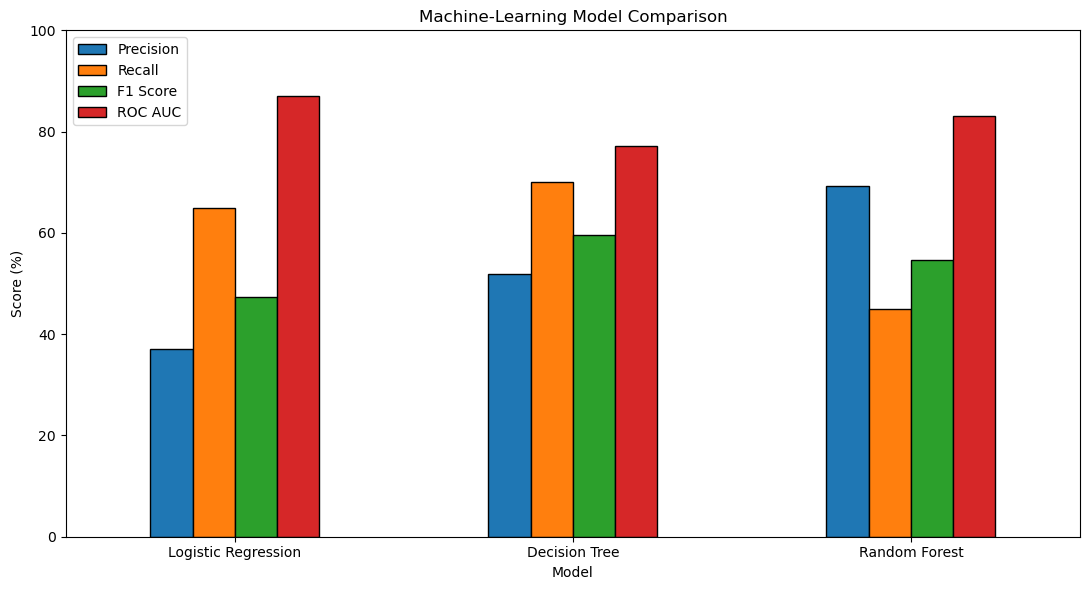

In [12]:
chart_data = percentage_results.set_index("Model")[[
 "Precision", "Recall", "F1 Score", "ROC AUC"
]]
chart_data.plot(
 kind="bar",
    figsize=(11, 6),
 edgecolor="black")
plt.title("Machine-Learning Model Comparison")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [13]:
best_row = results_df.loc[
 results_df["F1 Score"].idxmax()
]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)
print("Best F1-score:", round(
 best_row["F1 Score"] * 100, 2
), "%")

Best model: Decision Tree
Best F1-score: 59.57 %


In [14]:
best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(
 X_test
)[:, 1]
print(classification_report(
 y_test,
 best_predictions,
 target_names=["No Incident", "Incident"],
 zero_division=0
))

              precision    recall  f1-score   support

 No Incident       0.97      0.93      0.95       180
    Incident       0.52      0.70      0.60        20

    accuracy                           0.91       200
   macro avg       0.74      0.81      0.77       200
weighted avg       0.92      0.91      0.91       200



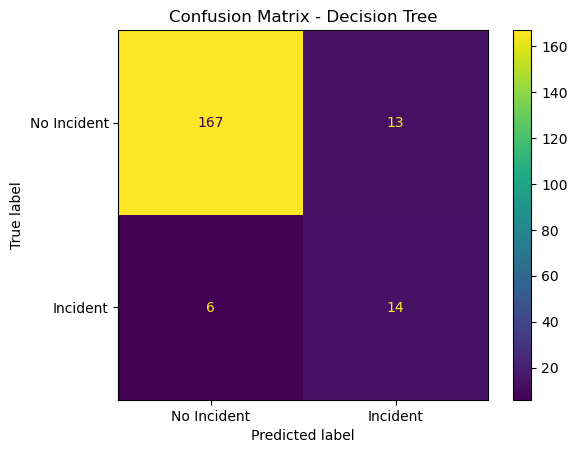

In [16]:
cm = confusion_matrix(y_test, best_predictions)
ConfusionMatrixDisplay(
 confusion_matrix=cm,
 display_labels=["No Incident", "Incident"]
).plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

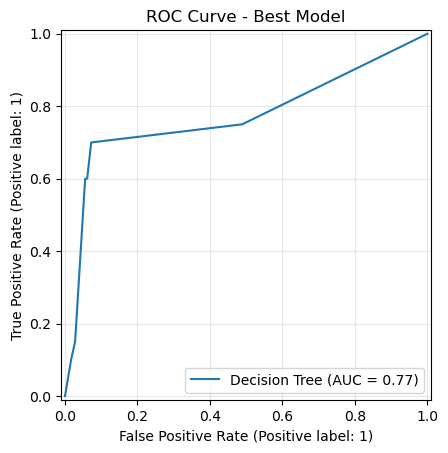

In [17]:
RocCurveDisplay.from_predictions(
 y_test,
 best_probabilities,
 name=best_model_name
)
plt.title("ROC Curve - Best Model")
plt.grid(alpha=0.3)
plt.show()

In [18]:
cv = StratifiedKFold(
 n_splits=5,
 shuffle=True,
 random_state=42
)
cv_f1_scores = cross_val_score(
 best_model,
 X_train,
 y_train,
 cv=cv,
 scoring="f1"
)
print("F1 scores:", np.round(cv_f1_scores, 3))
print("Average F1-score:", round(
 cv_f1_scores.mean() * 100, 2
), "%")

F1 scores: [0.364 0.324 0.32  0.349 0.333]
Average F1-score: 33.81 %


In [19]:
alert_threshold = 0.40
threshold_predictions = (
 best_probabilities >= alert_threshold
).astype(int)
print("Precision:", round(
 precision_score(
 y_test, threshold_predictions,
 zero_division=0
 ) * 100, 2
), "%")
print("Recall:", round(
 recall_score(
 y_test, threshold_predictions,
 zero_division=0
 ) * 100, 2
), "%")

Precision: 51.85 %
Recall: 70.0 %


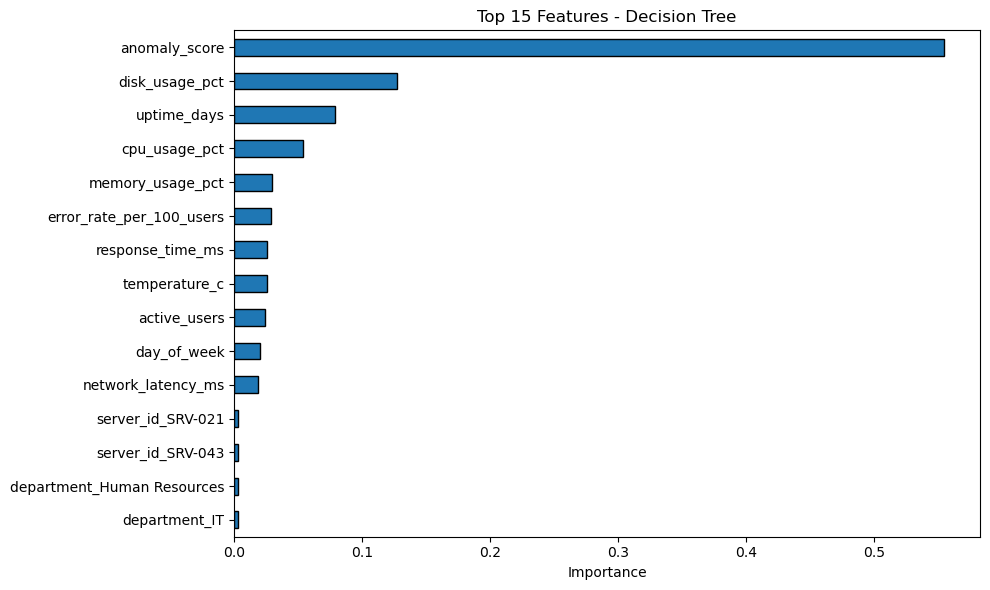

In [20]:
if hasattr(best_model, "feature_importances_"):
 feature_importance = pd.Series(
 best_model.feature_importances_,
 index=X_train.columns
 ).sort_values(ascending=False).head(15)
 feature_importance.sort_values().plot(
 kind="barh",
 figsize=(10, 6),
 edgecolor="black"
 )
 plt.title(f"Top 15 Features - {best_model_name}")
 plt.xlabel("Importance")
 plt.tight_layout()
 plt.show()
else:
 print("Feature importance is not available.")

In [21]:
percentage_results.to_csv(
 "Phase5_Model_Comparison.csv",
 index=False
)
joblib.dump(
 best_model,
 "best_it_incident_model.pkl"
)
prediction_results = pd.DataFrame({
 "Actual": y_test.reset_index(drop=True),
 "Predicted": best_predictions,
 "Incident_Probability": best_probabilities.round(4),
 "Alert_Threshold_040": threshold_predictions
})
prediction_results.to_csv(
 "Phase5_Final_Predictions.csv",
 index=False
)
print("Phase 5 files saved successfully!")

Phase 5 files saved successfully!


In [22]:
print("=" * 60)
print("PHASE 5 - MODEL EVALUATION SUMMARY")
print("=" * 60)
print("Models compared:", len(results_df))
print("Best model:", best_model_name)
print("Accuracy:", round(
 best_row["Accuracy"] * 100, 2
), "%")
print("Precision:", round(
 best_row["Precision"] * 100, 2
), "%")
print("Recall:", round(
 best_row["Recall"] * 100, 2
), "%")
print("F1-score:", round(
 best_row["F1 Score"] * 100, 2
), "%")
print("ROC-AUC:", round(
 best_row["ROC AUC"] * 100, 2
), "%")
print("Phase 5 completed successfully!")

PHASE 5 - MODEL EVALUATION SUMMARY
Models compared: 3
Best model: Decision Tree
Accuracy: 90.5 %
Precision: 51.85 %
Recall: 70.0 %
F1-score: 59.57 %
ROC-AUC: 77.25 %
Phase 5 completed successfully!
